# Notebook 5 — Çıktılar ve Sunum Hazırlığı

## Bu notebook ne yapıyor?

Bu son notebook. Tüm analizimizi **sunulabilir çıktılara** dönüştürüyoruz.

Üreteceğimiz çıktılar:
1. **Yönetici özeti tablosu** — tek bakışta tüm kilit rakamlar
2. **MDC maliyet özet tablosu** — kategori bazında maliyet referansı
3. **Model performans kartı** — tek görselde tüm metrikler
4. **Sunum taslağı** — 15 dakikalık konuşma planı

**Amaç:** SJGHC mülakatında 15 dakikalık PowerPoint sunumu için hazır malzeme.


---
## 5.0 — Kurulum ve Artefakt Yükleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGS = ROOT / "figures"
REPORTS = ROOT / "reports"

# Temiz veri
df = pd.read_parquet(ROOT / "data/processed/hcp_clean.parquet")

# Model metrikleri
with open(REPORTS / "model_metrics.json") as f:
    metrics = json.load(f)

print(f"Veri        : {df.shape[0]:,} epizod × {df.shape[1]} sütun")
print(f"Model R²    : {metrics['aud_r2']}")
print(f"Model MAE   : ${metrics['aud_mae']:,.2f}")
print("Artefaktlar yüklendi ✓")


Veri        : 30,615 epizod × 109 sütun
Model R²    : 0.805
Model MAE   : $751.39
Artefaktlar yüklendi ✓


---
## 5.1 — Yönetici Özeti Tablosu

**Yönetici özeti nedir?**  
SJGHC'deki bir yönetici 30 saniyede tüm projeyi anlamak ister.  
Bu tablo, "ne yaptık, ne bulduk" sorularını tek bakışta cevaplar.


In [2]:
summary_rows = [
    ("Veri Seti", "Toplam Epizod", f"{len(df):,}"),
    ("Veri Seti", "Analiz Dönemi", "2023 (12 ay)"),
    ("Veri Seti", "Hastane Tipi", "Özel akut bakım (HospitalType=2)"),
    ("Hasta Profili", "Medyan Yaş", f"{df['Age'].median():.0f} yaş"),
    ("Hasta Profili", "65+ Yaş Oranı", f"%{(df['Age']>=65).mean()*100:.1f}"),
    ("Hasta Profili", "Günübirlik Oranı", f"%{(df['LOS']==0).mean()*100:.1f}"),
    ("Maliyet", "Medyan Fatura", f"${df['total_charge_aud'].median():,.0f}"),
    ("Maliyet", "Ortalama Fatura", f"${df['total_charge_aud'].mean():,.0f}"),
    ("Maliyet", "Maksimum Fatura", f"${df['total_charge_aud'].max():,.0f}"),
    ("En Sık MDC", "Kategori",
     f"L — Böbrek/Üriner (%{(df['MDC']=='L').mean()*100:.1f})"),
    ("Model", "Algoritma", "XGBoost Regressor"),
    ("Model", "Doğruluk (R²)", f"{metrics['aud_r2']:.3f}"),
    ("Model", "Ortalama Hata (MAE)", f"${metrics['aud_mae']:,.0f}"),
    ("Model", "Yüzde Hata (MAPE)", f"%{metrics['mape_pct']:.1f}"),
]

exec_summary = pd.DataFrame(summary_rows, columns=["Kategori", "Metrik", "Değer"])
exec_summary.to_csv(REPORTS / "executive_summary.csv", index=False)
print("✓ Kaydedildi: reports/executive_summary.csv\n")
print(exec_summary.to_string(index=False))


✓ Kaydedildi: reports/executive_summary.csv

     Kategori              Metrik                            Değer
    Veri Seti       Toplam Epizod                           30,615
    Veri Seti       Analiz Dönemi                     2023 (12 ay)
    Veri Seti        Hastane Tipi Özel akut bakım (HospitalType=2)
Hasta Profili          Medyan Yaş                           67 yaş
Hasta Profili       65+ Yaş Oranı                            %54.8
Hasta Profili    Günübirlik Oranı                            %78.4
      Maliyet       Medyan Fatura                             $650
      Maliyet     Ortalama Fatura                           $2,685
      Maliyet     Maksimum Fatura                          $69,138
   En Sık MDC            Kategori        L — Böbrek/Üriner (%32.7)
        Model           Algoritma                XGBoost Regressor
        Model       Doğruluk (R²)                            0.805
        Model Ortalama Hata (MAE)                             $751
        Model   Y

---
## 5.2 — MDC Bazında Maliyet Özet Tablosu

Funding & Costing ekibinin en çok işine yarayacak tablo:  
**"Her hastalık kategorisi ortalama ne kadara mal oluyor?"**

Bu tablo gelecekte bütçe planlaması için referans olabilir.


In [3]:
MDC_MAP = {
    "A":"Pre-MDC","B":"Sinir Sistemi","C":"Göz","D":"KBB & Ağız",
    "E":"Solunum","F":"Dolaşım","G":"Sindirim","H":"Karaciğer/Safra",
    "I":"Kas-İskelet","J":"Deri","K":"Endokrin","L":"Böbrek/Üriner",
    "M":"Erkek Üreme","N":"Kadın Üreme","O":"Gebelik/Doğum","P":"Yenidoğan",
    "Q":"Kan","R":"Ruhsal","S":"Madde Kullanımı","T":"Enfeksiyon",
    "U":"Yanık","V":"Sağlık Faktörleri","W":"Yaralanma","X":"Diğer",
    "Y":"HIV","Z":"Gruplandırılamayan",
}

mdc_summary = (df.groupby("MDC")
                 .agg(Epizod=("total_charge_aud", "count"),
                      Medyan=("total_charge_aud", "median"),
                      Ortalama=("total_charge_aud", "mean"),
                      Toplam=("total_charge_aud", "sum"),
                      Ort_LOS=("LOS", "mean"),
                      Ort_Yas=("Age", "mean"))
                 .reset_index())
mdc_summary["Kategori"] = mdc_summary["MDC"].map(MDC_MAP)
mdc_summary["Pay_%"] = (mdc_summary["Epizod"] / len(df) * 100).round(1)
mdc_summary = mdc_summary.sort_values("Toplam", ascending=False)

# Yuvarla
for col in ["Medyan", "Ortalama", "Toplam"]:
    mdc_summary[col] = mdc_summary[col].round(0)
mdc_summary["Ort_LOS"] = mdc_summary["Ort_LOS"].round(2)
mdc_summary["Ort_Yas"] = mdc_summary["Ort_Yas"].round(1)

# Sütun sırası
mdc_summary = mdc_summary[["MDC","Kategori","Epizod","Pay_%",
                            "Medyan","Ortalama","Toplam","Ort_LOS","Ort_Yas"]]
mdc_summary.to_csv(REPORTS / "mdc_cost_summary.csv", index=False)
print("✓ Kaydedildi: reports/mdc_cost_summary.csv\n")

# En pahalı 10 kategoriyi göster
print("Toplam maliyete göre en yüksek 10 MDC kategorisi:")
print("-" * 80)
top10 = mdc_summary.head(10).copy()
top10["Medyan"]   = top10["Medyan"].apply(lambda x: f"${x:,.0f}")
top10["Ortalama"] = top10["Ortalama"].apply(lambda x: f"${x:,.0f}")
top10["Toplam"]   = top10["Toplam"].apply(lambda x: f"${x:,.0f}")
print(top10.to_string(index=False))


✓ Kaydedildi: reports/mdc_cost_summary.csv

Toplam maliyete göre en yüksek 10 MDC kategorisi:
--------------------------------------------------------------------------------
MDC      Kategori  Epizod  Pay_% Medyan Ortalama      Toplam  Ort_LOS  Ort_Yas
  I   Kas-İskelet    2945    9.6 $6,684   $9,127 $26,880,086     1.80     60.6
  F       Dolaşım    1691    5.5 $4,718   $6,720 $11,362,894     1.81     69.8
  G      Sindirim    1707    5.6 $1,580   $3,488  $5,953,212     1.02     60.6
  L Böbrek/Üriner   10001   32.7   $357     $556  $5,564,309     0.10     66.1
  C           Göz    1549    5.1 $2,636   $2,862  $4,433,231     0.01     71.7
  R        Ruhsal    6965   22.8   $480     $625  $4,355,261     0.04     66.8
  N   Kadın Üreme     662    2.2 $4,231   $4,814  $3,186,692     1.01     46.9
  O Gebelik/Doğum     513    1.7 $6,880   $5,745  $2,947,391     2.82     32.2
  K      Endokrin     372    1.2 $8,774   $7,450  $2,771,262     2.51     52.1
  J          Deri     551    1.8 $3

---
## 5.3 — Model Performans Kartı

Tek bir görselde modelin tüm performansını özetliyoruz.  
Bu, sunumda **"Modelimiz ne kadar iyi?"** slaytı olacak.


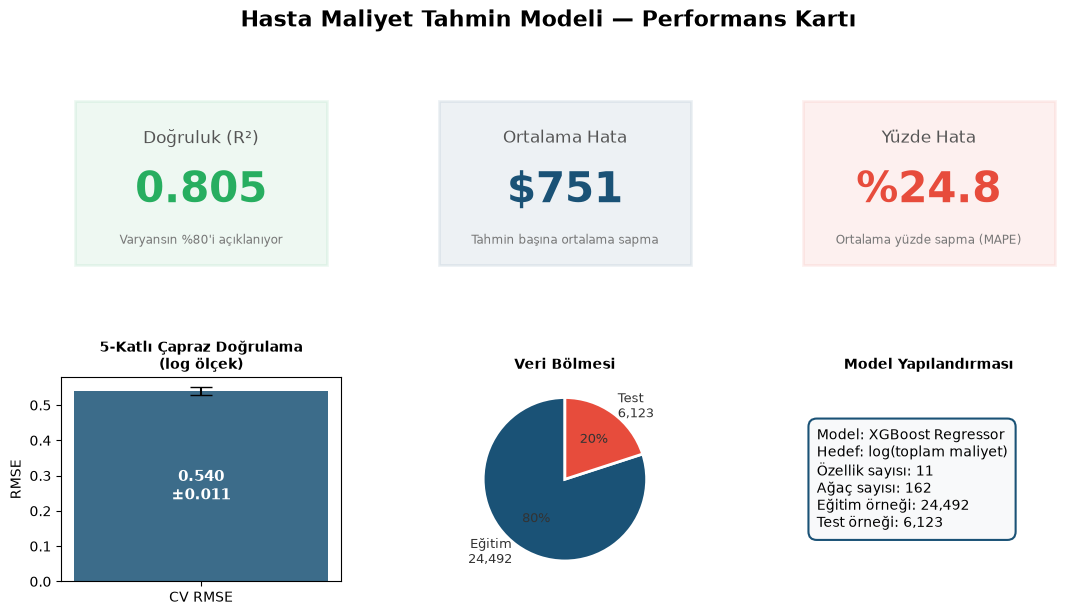

  ✓ Kaydedildi: 05_model_scorecard.png


In [4]:
fig = plt.figure(figsize=(13, 6.5))
fig.patch.set_facecolor("white")
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.3)

PRIMARY = "#1a5276"
ACCENT  = "#e74c3c"
GREEN   = "#27ae60"

# ─── Üst sıra: 3 büyük metrik kartı ───
metric_cards = [
    ("Doğruluk (R²)", f"{metrics['aud_r2']:.3f}",
     f"Varyansın %{metrics['aud_r2']*100:.0f}'i açıklanıyor", GREEN),
    ("Ortalama Hata", f"${metrics['aud_mae']:,.0f}",
     "Tahmin başına ortalama sapma", PRIMARY),
    ("Yüzde Hata", f"%{metrics['mape_pct']:.1f}",
     "Ortalama yüzde sapma (MAPE)", ACCENT),
]
for i, (title, value, sub, color) in enumerate(metric_cards):
    ax = fig.add_subplot(gs[0, i])
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.05, 0.1), 0.9, 0.8,
                 facecolor=color, alpha=0.08,
                 edgecolor=color, linewidth=2, transform=ax.transAxes))
    ax.text(0.5, 0.72, title, ha="center", va="center",
            fontsize=12, color="#555", transform=ax.transAxes)
    ax.text(0.5, 0.46, value, ha="center", va="center",
            fontsize=30, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, sub, ha="center", va="center",
            fontsize=8.5, color="#777", transform=ax.transAxes, wrap=True)

# ─── Alt sol: CV skorları ───
ax_cv = fig.add_subplot(gs[1, 0])
cv_mean, cv_std = metrics["cv_rmse_mean"], metrics["cv_rmse_std"]
ax_cv.bar(["CV RMSE"], [cv_mean], yerr=[cv_std], color=PRIMARY,
          capsize=8, width=0.5, alpha=0.85)
ax_cv.set_title("5-Katlı Çapraz Doğrulama\n(log ölçek)", fontsize=10, fontweight="bold")
ax_cv.set_ylabel("RMSE")
ax_cv.text(0, cv_mean/2, f"{cv_mean:.3f}\n±{cv_std:.3f}",
           ha="center", va="center", color="white", fontweight="bold", fontsize=11)

# ─── Alt orta: Eğitim/Test bölme ───
ax_split = fig.add_subplot(gs[1, 1])
sizes = [metrics["n_train"], metrics["n_test"]]
labels = [f"Eğitim\n{metrics['n_train']:,}", f"Test\n{metrics['n_test']:,}"]
ax_split.pie(sizes, labels=labels, colors=[PRIMARY, ACCENT],
             autopct="%1.0f%%", startangle=90,
             textprops={"fontsize": 9, "color": "#333"},
             wedgeprops={"edgecolor": "white", "linewidth": 2})
ax_split.set_title("Veri Bölmesi", fontsize=10, fontweight="bold")

# ─── Alt sağ: Özellik bilgisi ───
ax_feat = fig.add_subplot(gs[1, 2])
ax_feat.axis("off")
feat_text = (
    f"Model: XGBoost Regressor\n"
    f"Hedef: log(toplam maliyet)\n"
    f"Özellik sayısı: {len(metrics['features'])}\n"
    f"Ağaç sayısı: {metrics['best_iter']}\n"
    f"Eğitim örneği: {metrics['n_train']:,}\n"
    f"Test örneği: {metrics['n_test']:,}"
)
ax_feat.text(0.1, 0.5, feat_text, ha="left", va="center",
             fontsize=10, transform=ax_feat.transAxes,
             bbox=dict(boxstyle="round,pad=0.6", facecolor="#f8f9fa",
                       edgecolor=PRIMARY, linewidth=1.5))
ax_feat.set_title("Model Yapılandırması", fontsize=10, fontweight="bold")

fig.suptitle("Hasta Maliyet Tahmin Modeli — Performans Kartı",
             fontsize=16, fontweight="bold", y=0.99)
plt.savefig(FIGS / "05_model_scorecard.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("  ✓ Kaydedildi: 05_model_scorecard.png")


---
## 5.4 — 15 Dakikalık Sunum Taslağı

Mülakat sunumu için slayt-slayt konuşma planı.  
Her slayt için: başlık, kullanılacak görsel, konuşma noktaları.


In [5]:
outline = f'''# SJGHC Case Study — Sunum Taslağı (15 Dakika)
## Data Scientist (Funding & Costing) — Mülakat Sunumu

---

### Slayt 1 — Başlık (30 sn)
- **Başlık:** Hastane Epizod Maliyet Tahmini — HCP Veri Analizi
- İsim, pozisyon, tarih
- "30,615 hasta epizodunu analiz ettim ve maliyet tahmin modeli geliştirdim"

### Slayt 2 — Problem & Yaklaşım (1.5 dk)
- **Soru:** Bir hastanın maliyetini taburculuk öncesi tahmin edebilir miyiz?
- **Neden önemli:** Bütçe planlaması, kaynak tahsisi, fiyatlandırma
- **Yaklaşım:** 6 aşamalı pipeline (veri → temizlik → EDA → model → çıktı)

### Slayt 3 — Veri Genel Bakış (1.5 dk)
- **Görsel:** figures/01_categorical_distributions.png
- 30,615 epizod, 2023, özel akut hastane
- %78 günübirlik, medyan yaş 67, %55 65 yaş üstü
- **Veri kalitesi notu:** 27 sütun tamamen boştu (whitespace padding keşfi)

### Slayt 4 — Maliyet Dağılımı (1.5 dk)
- **Görsel:** figures/03_charge_distribution.png
- Sağa çarpık: medyan ${df['total_charge_aud'].median():,.0f}, ortalama ${df['total_charge_aud'].mean():,.0f}
- **Karar:** Modeli log ölçekte eğittim → aykırı vakaların etkisini azalttım

### Slayt 5 — Kilit Bulgu: MDC Maliyet Farkı (2 dk)
- **Görsel:** figures/03_mdc_cost.png
- Kategoriler arası 25 kat fark
- Böbrek/Üriner (en sık) aslında en ucuz → diyaliz günübirlik
- **Funding içgörüsü:** Hacim ≠ maliyet

### Slayt 6 — Maliyet Sürücüleri (2 dk)
- **Görsel:** figures/03_los_vs_cost.png + figures/03_comorbidity_cost.png
- LOS=0 medyan ${df.loc[df['LOS']==0,'total_charge_aud'].median():,.0f} vs LOS>0 ${df.loc[df['LOS']>0,'total_charge_aud'].median():,.0f}
- Komorbidite arttıkça maliyet doğrusal artıyor

### Slayt 7 — Model Performansı (2 dk)
- **Görsel:** figures/05_model_scorecard.png + figures/04_actual_vs_predicted.png
- XGBoost, R² = {metrics['aud_r2']:.3f}, MAE = ${metrics['aud_mae']:,.0f}
- 5-katlı CV ile doğrulandı (kararlı: ±{metrics['cv_rmse_std']:.3f})

### Slayt 8 — Model Yorumlanabilirliği: SHAP (2 dk)
- **Görsel:** figures/04_shap_summary.png
- En güçlü sürücüler: Prosedür sayısı, MDC, LOS
- **Önemli:** Model genç diyaliz hastalarının ucuz olduğunu kendi öğrendi
- "Kara kutu değil — her tahmini açıklayabiliyoruz"

### Slayt 9 — İş Etkisi & Sonraki Adımlar (1.5 dk)
- Bütçe tahmini, anomali tespiti (beklenenden pahalı vakalar)
- Sonraki adım: gerçek maliyet (charge değil) verisiyle eğitim
- Daha fazla özellik: spesifik tanı kodları, doktor, koğuş

### Slayt 10 — Teşekkür & Sorular (30 sn)
- GitHub repo linki
- Sorular

---

## Olası Mülakat Soruları ve Cevaplar

**S: Neden XGBoost?**
C: Çarpık, karma (kategorik+sayısal) tıbbi veride en iyi performans. SHAP ile yorumlanabilir.

**S: R² 0.80 yeterli mi?**
C: Sağlık maliyet tahmininde iyi bir sonuç. Charge verisi gerçek maliyet değil; gerçek maliyet verisiyle daha da iyileşir.

**S: Veri sızıntısı (data leakage) riski?**
C: LOS taburculukta belli olur — modelim taburculuk-sonrası tahmin için. Gerçek-zamanlı tahmin için LOS çıkarılmalı.

**S: Eksik veriyi nasıl ele aldın?**
C: Whitespace padding'i tespit ettim (pd.NA değil), %100 boş 27 sütunu çıkardım, kalan boşlukları sayım özelliğine çevirdim.

**S: Etik/gizlilik?**
C: Veri de-identified. Confidential dosyalar .gitignore ile dışlandı, repoda asla yer almadı.
'''

with open(REPORTS / "presentation_outline.md", "w") as f:
    f.write(outline)
print("✓ Kaydedildi: reports/presentation_outline.md")
print(f"  ({len(outline.splitlines())} satır sunum taslağı)")


✓ Kaydedildi: reports/presentation_outline.md
  (75 satır sunum taslağı)


---
## 5.5 — Tüm Çıktıların Envanteri

Projeyi tamamladık. İşte ürettiğimiz her şeyin listesi.


In [6]:
print("=" * 65)
print("SJGHC CASE STUDY — PROJE ÇIKTI ENVANTERİ")
print("=" * 65)

print("\n📓 NOTEBOOKS:")
for nb_file in sorted((ROOT / "notebooks").glob("*.ipynb")):
    print(f"   {nb_file.name}")

print("\n📊 FIGURES (Sunum Grafikleri):")
for fig_file in sorted(FIGS.glob("*.png")):
    size_kb = fig_file.stat().st_size / 1024
    print(f"   {fig_file.name:<42} {size_kb:>6.1f} KB")

print("\n📄 REPORTS (Tablolar & Çıktılar):")
for rep_file in sorted(REPORTS.glob("*")):
    if rep_file.is_file():
        size_kb = rep_file.stat().st_size / 1024
        print(f"   {rep_file.name:<42} {size_kb:>6.1f} KB")

print("\n💾 DATA (gitignored — gizli):")
for data_file in sorted((ROOT / "data/processed").glob("*.parquet")):
    size_mb = data_file.stat().st_size / 1024**2
    print(f"   {data_file.name:<42} {size_mb:>6.2f} MB")

print("\n" + "=" * 65)
print("✅ PROJE TAMAMLANDI")
print("=" * 65)
print(f'''
  6 notebook | {len(list(FIGS.glob("*.png")))} grafik | Model R² = {metrics['aud_r2']:.3f}

  Sıradaki adımlar (senin için):
  1. reports/presentation_outline.md ile slaytları hazırla
  2. figures/ klasöründeki PNG'leri slaytlara ekle
  3. GitHub repo linkini sunuma koy
  4. 30 Haziran 09:00 AWST'den önce Stephen.Lamb@sjog.org.au'ya gönder
''')


SJGHC CASE STUDY — PROJE ÇIKTI ENVANTERİ

📓 NOTEBOOKS:
   00_setup_load.ipynb
   01_data_understanding.ipynb
   02_cleaning_features.ipynb
   03_eda.ipynb
   04_modeling.ipynb
   05_outputs_export.ipynb

📊 FIGURES (Sunum Grafikleri):
   01_categorical_distributions.png            203.7 KB
   01_null_map.png                              68.6 KB
   03_age_cost.png                              72.3 KB
   03_charge_distribution.png                   89.8 KB
   03_comorbidity_cost.png                      63.5 KB
   03_los_vs_cost.png                          112.9 KB
   03_mdc_cost.png                             120.5 KB
   03_monthly_trend.png                         90.4 KB
   03_sameday_vs_overnight.png                  90.3 KB
   04_actual_vs_predicted.png                  155.9 KB
   04_feature_importance.png                    50.7 KB
   04_shap_summary.png                         108.9 KB
   05_model_scorecard.png                      111.1 KB

📄 REPORTS (Tablolar & Çıktılar):
   .